# Does ARIMA beat a random walk on Brent crude?

The coursework analysis in `submission/` compares AR(1), MA(1), MA(2), ARMA(1,1)
and an auto-selected ARIMA against **each other**, on a single 14-month hold-out
split, and concludes that auto-ARIMA wins.

Two things are missing, and this notebook adds them:

1. **A benchmark.** For an I(1) price series the model to beat is a random walk.
   Without it, a MAPE figure says nothing about whether a model has any skill.
2. **More than one test window.** Fourteen observations cannot separate five
   models, a limitation the submission itself notes.

Here the models are refit at 74 rolling origins, compared against random-walk
baselines, tested with Diebold-Mariano and Clark-West, and re-run from three
different start origins to check the answer is stable.

This notebook reads the saved output in `results/`. It does not refit anything:
the backtest takes about half an hour, and reading committed results keeps what
you see here identical to what the scripts produced.

In [1]:
if (basename(getwd()) == "analysis") setwd("..")
options(jupyter.plot_mimetypes = "image/png", repr.plot.res = 170)
source("R/data.R")

d <- load_brent()
cat(sprintf("%d monthly observations, %s to %s\n", d$n,
            format(min(d$dates)), format(max(d$dates))))
cat(sprintf("%d log-returns\n", length(d$diff_y)))

135 monthly observations, 2015-01-31 to 2026-03-31


134 log-returns


## 1. The series

Eleven years of monthly Brent, spanning the 2020 collapse and the 2022 spike.
The shaded region marks the months used as backtest origins.

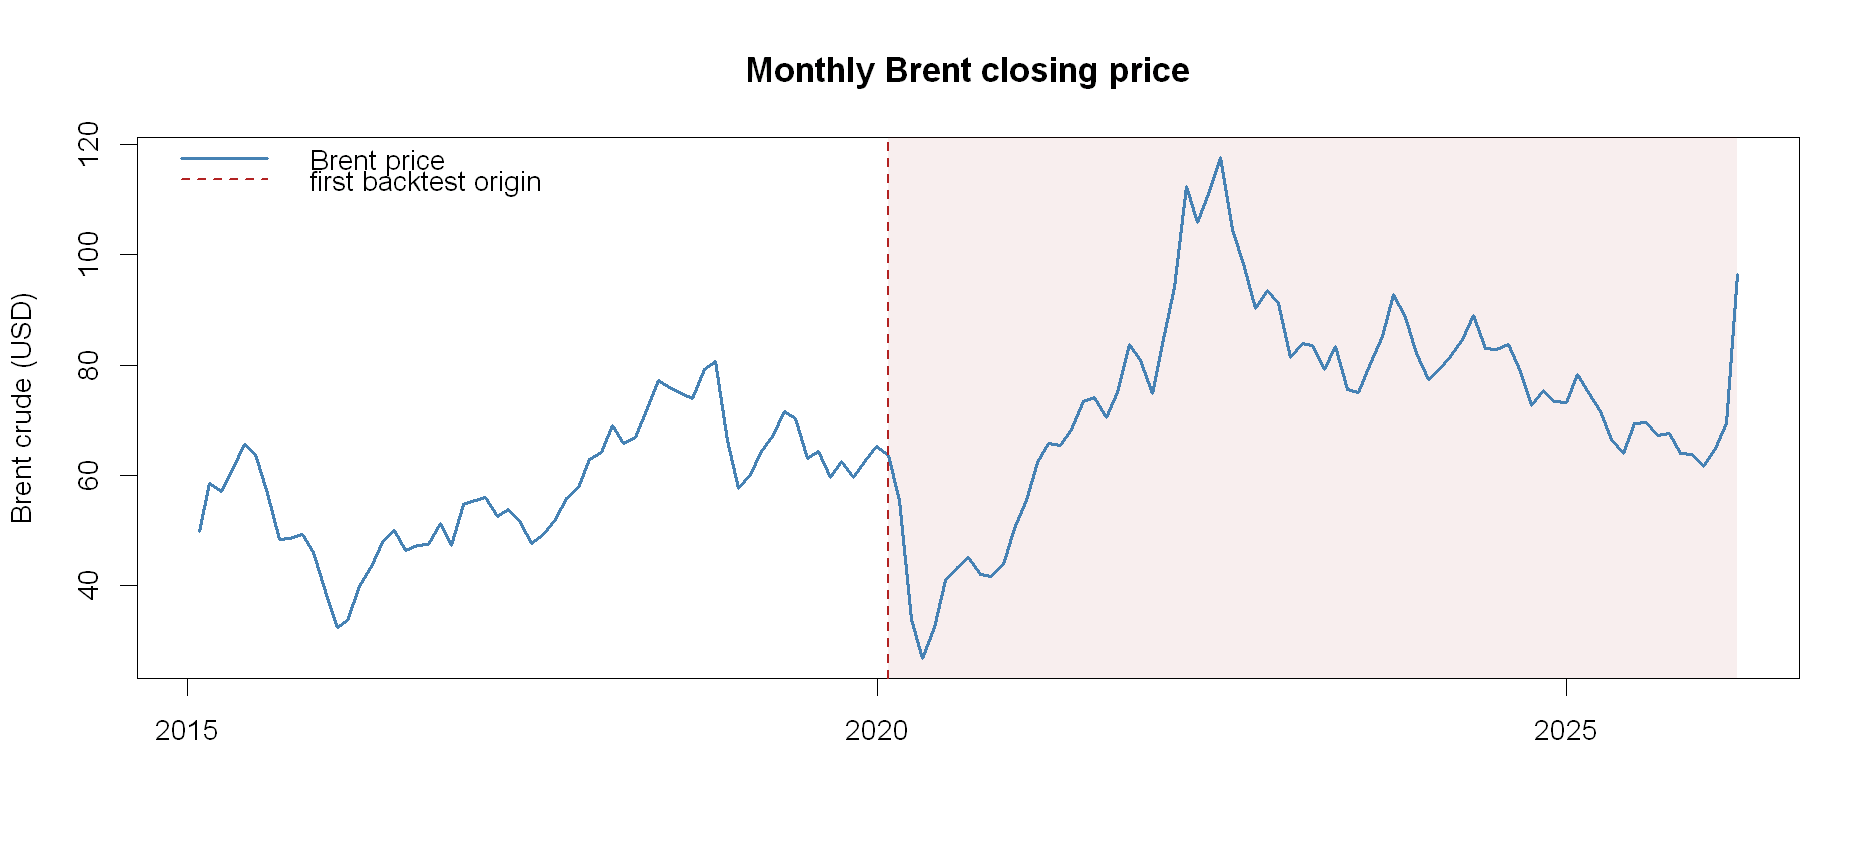

In [2]:
options(repr.plot.width = 11, repr.plot.height = 5)
plot(d$dates, d$y, type = "l", col = "steelblue", lwd = 1.8,
     xlab = "", ylab = "Brent crude (USD)", main = "Monthly Brent closing price")
rect(d$dates[61], par("usr")[3], max(d$dates), par("usr")[4],
     col = adjustcolor("firebrick", 0.07), border = NA)
lines(d$dates, d$y, col = "steelblue", lwd = 1.8)
abline(v = d$dates[61], col = "firebrick", lty = 2, lwd = 1.6)
legend("topleft", bty = "n",
       legend = c("Brent price", "first backtest origin"),
       col = c("steelblue", "firebrick"), lty = c(1, 2), lwd = c(1.8, 1.6))

## 2. The benchmark that was missing

The naive random walk forecasts next month's price as this month's price. No
parameters, no estimation. Any model that cannot beat it is not adding value.

A random walk with drift is included too: it extrapolates the average
log-return, which is the natural "trend continues" benchmark.

In [3]:
source("R/models.R")
source("R/baselines.R")

sp     <- submission_split(d)
naive  <- fit_naive_rw(sp$train)
drift  <- fit_rw_drift(sp$train)

cat(sprintf("naive RW  : forecast log-return 0 at every horizon, sigma2 = %.6f\n", naive$sigma2))
cat(sprintf("RW + drift: forecast log-return %.6f per month\n", drift$mu))

naive RW  : forecast log-return 0 at every horizon, sigma2 = 0.008942


RW + drift: forecast log-return 0.003787 per month


## 3. Rolling-origin backtest

At each origin every model is refit on the data available up to that point and
forecasts 1, 6 and 12 months ahead. Forecasts are converted back to USD with the
lognormal bias correction, and scored against the observed price.

This gives 74 forecasts per model at h=1, 69 at h=6 and 63 at h=12, instead of
one 14-month path.

In [4]:
metrics <- read.csv("results/metrics.csv", stringsAsFactors = FALSE)
for (hh in c(1, 6, 12)) {
  s <- metrics[metrics$h == hh, c("model", "n_origins", "RMSE", "MAE", "MAPE")]
  s <- s[order(s$RMSE), ]
  cat(sprintf("\n--- h = %d month%s ---\n", hh, if (hh == 1) "" else "s"))
  print(format(s, digits = 4), row.names = FALSE)
}


--- h = 1 month ---
             model n_origins  RMSE   MAE  MAPE
             AR(1)        74 6.696 5.007 7.172
             MA(1)        74 6.710 4.928 6.984
         ARMA(1,1)        74 6.759 4.956 7.000
 Naive RW (bias-c)        74 6.767 5.045 7.422
          Naive RW        74 6.772 5.041 7.410
        RW + drift        74 6.811 5.083 7.480
             MA(2)        74 6.845 5.016 7.074
        Auto-ARIMA        74 7.235 5.288 7.228

--- h = 6 months ---
             model n_origins  RMSE   MAE  MAPE
          Naive RW        69 15.35 12.06 15.87
 Naive RW (bias-c)        69 15.42 12.37 16.34
        RW + drift        69 16.17 12.94 17.20
             MA(1)        69 16.37 12.89 17.12
             AR(1)        69 16.50 12.79 16.95
         ARMA(1,1)        69 16.53 12.91 17.20
             MA(2)        69 16.71 12.85 17.10
        Auto-ARIMA        69 18.43 13.27 16.75

--- h = 12 months ---
             model n_origins  RMSE   MAE  MAPE
          Naive RW        63 22.77 18.42 

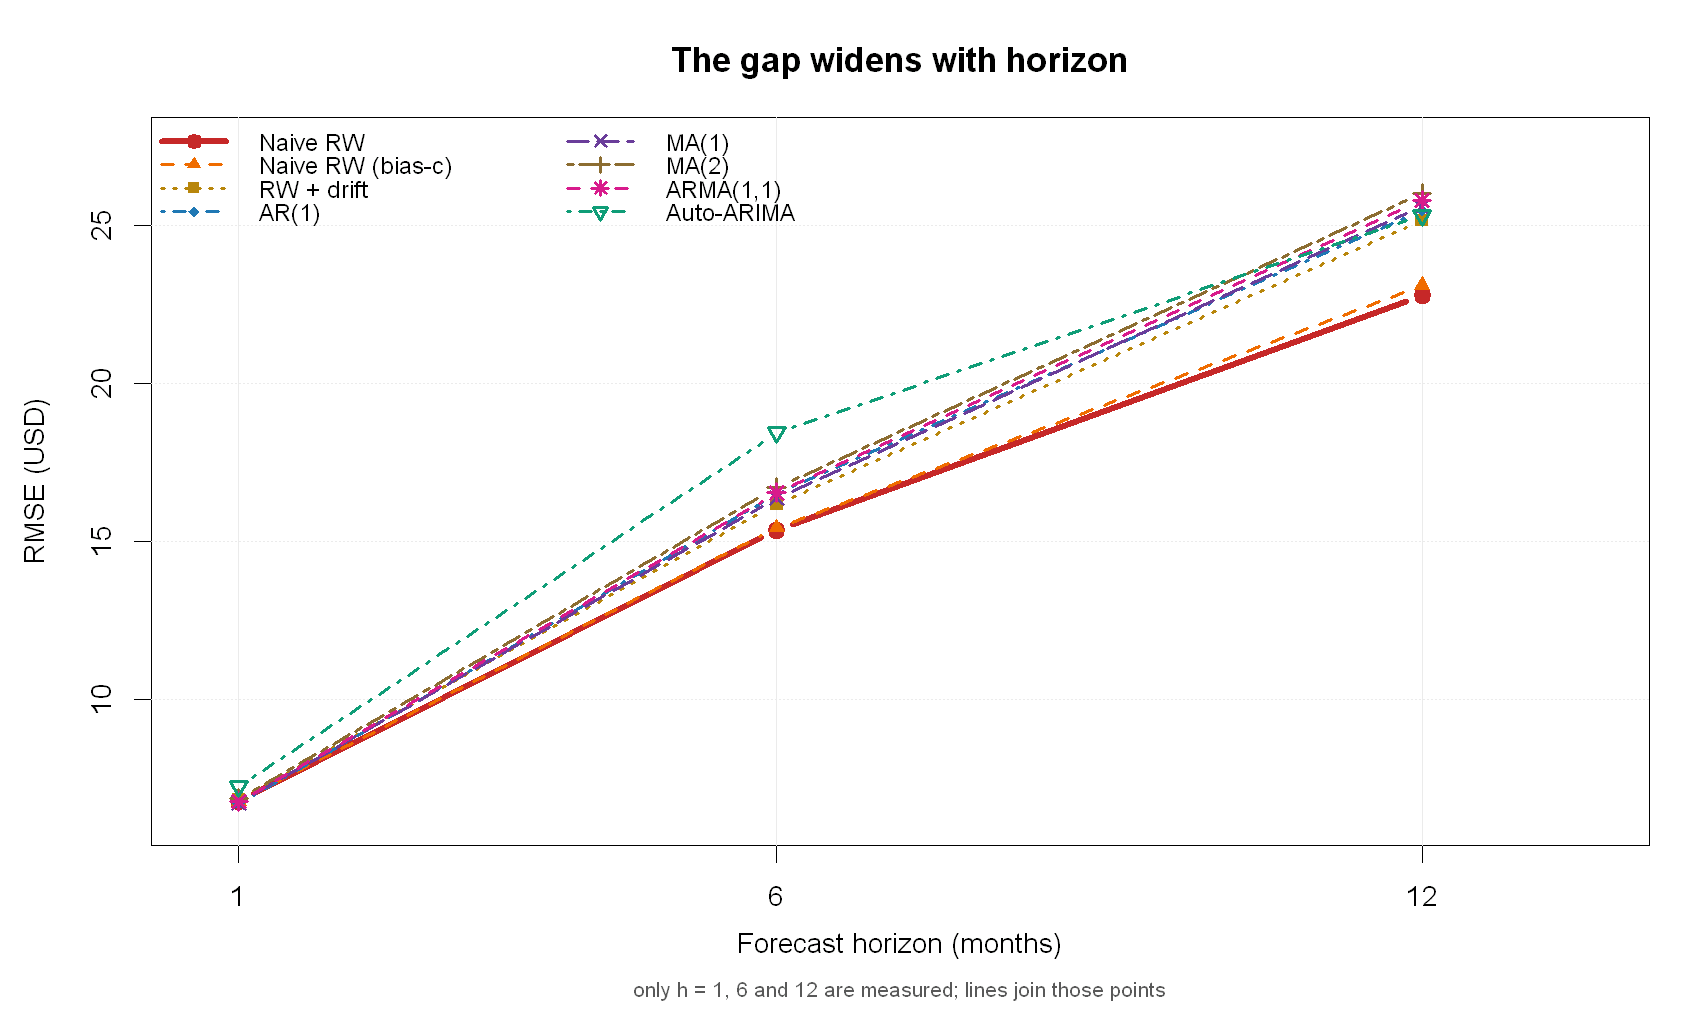

In [5]:
options(repr.plot.width = 10, repr.plot.height = 6)
model_order <- c("Naive RW", "Naive RW (bias-c)", "RW + drift",
                 "AR(1)", "MA(1)", "MA(2)", "ARMA(1,1)", "Auto-ARIMA")
cols <- c("#C62828", "#EF6C00", "#B8860B", "#1F78B4",
          "#6A3D9A", "#8C6D31", "#D81B8C", "#0F9D77")
pchs <- c(19, 17, 15, 18, 4, 3, 8, 6)
ltys <- c(1, 2, 3, 4, 5, 6, 2, 4)
lwds <- c(3.4, 1.7, 1.7, 1.7, 1.7, 1.7, 1.7, 1.7)
names(cols) <- names(pchs) <- names(ltys) <- names(lwds) <- model_order

par(mar = c(5.2, 4.5, 3.5, 1.5))
plot(NA, xlim = c(0.7, 13.6), ylim = range(metrics$RMSE) * c(0.93, 1.06),
     xaxt = "n", xlab = "", ylab = "RMSE (USD)",
     main = "The gap widens with horizon")
axis(1, at = c(1, 6, 12), lwd = 0, lwd.ticks = 1)
mtext("Forecast horizon (months)", side = 1, line = 2.4)
mtext("only h = 1, 6 and 12 are measured; lines join those points",
      side = 1, line = 3.7, cex = 0.75, col = "grey35")
grid(nx = NA, ny = NULL, col = "grey92")
abline(v = c(1, 6, 12), col = "grey92")
for (nm in model_order) {
  s <- metrics[metrics$model == nm, ]
  s <- s[order(s$h), ]
  lines(s$h, s$RMSE, col = cols[nm], type = "b", pch = pchs[nm],
        lwd = lwds[nm], lty = ltys[nm])
}
legend("topleft", bty = "n", cex = 0.85, ncol = 2,
       legend = model_order, col = cols[model_order],
       lwd = lwds[model_order], lty = ltys[model_order], pch = pchs[model_order])

At six and twelve months every model is worse than the naive walk, by 5% to 20%.
Auto-ARIMA, the winner of the single-split comparison, is the worst at h=1 and
h=6.

At one month the models sit within about 1% of the benchmark, which is small
enough that it needs a significance test rather than an eyeball.

## 4. Are the differences real?

**Diebold-Mariano** tests whether two forecast series have equal expected loss.
Two details matter. Multi-step forecasts from consecutive origins overlap, so
their loss differentials are autocorrelated: the variance is estimated with a
HAC estimator truncated at h-1. And with 63 to 74 origins the small-sample
Harvey-Leybourne-Newbold correction is not optional.

A random walk is AR(1) with phi = 0, so these comparisons are **nested**, and
Diebold-Mariano is undersized in that case. **Clark-West** is the appropriate
test, and both are reported.

In [6]:
dm <- read.csv("results/dm_tests.csv", stringsAsFactors = FALSE)
cat("Diebold-Mariano matches forecast::dm.test everywhere:",
    all(dm$dm_matches_pkg), "\n")

for (hh in c(1, 6, 12)) {
  s <- dm[dm$h == hh, ]
  s <- s[order(s$rmse_model), ]
  cat(sprintf("\n--- h = %d month%s, benchmark = Naive RW ---\n",
              hh, if (hh == 1) "" else "s"))
  print(data.frame(model = s$model,
                   RMSE  = round(s$rmse_model, 2),
                   DM_p  = round(s$dm_p, 3),
                   CW_p  = round(s$cw_p, 3),
                   verdict = ifelse(s$dm_p < 0.05, "different", "indistinguishable"),
                   stringsAsFactors = FALSE), row.names = FALSE)
}

Diebold-Mariano matches forecast::dm.test everywhere: TRUE 



--- h = 1 month, benchmark = Naive RW ---
             model RMSE  DM_p  CW_p           verdict
             AR(1) 6.70 0.821 0.071 indistinguishable
             MA(1) 6.71 0.850 0.034 indistinguishable
         ARMA(1,1) 6.76 0.972 0.041 indistinguishable
 Naive RW (bias-c) 6.77 0.902 0.357 indistinguishable
        RW + drift 6.81 0.505 0.671 indistinguishable
             MA(2) 6.84 0.862 0.056 indistinguishable
        Auto-ARIMA 7.23 0.265 0.120 indistinguishable

--- h = 6 months, benchmark = Naive RW ---
             model  RMSE  DM_p  CW_p           verdict
 Naive RW (bias-c) 15.42 0.932 0.436 indistinguishable
        RW + drift 16.17 0.395 0.765 indistinguishable
             MA(1) 16.37 0.457 0.623 indistinguishable
             AR(1) 16.50 0.368 0.666 indistinguishable
         ARMA(1,1) 16.53 0.427 0.612 indistinguishable
             MA(2) 16.71 0.418 0.570 indistinguishable
        Auto-ARIMA 18.43 0.472 0.635 indistinguishable

--- h = 12 months, benchmark = Naive RW 

Every one of the 21 comparisons is indistinguishable from the random walk under
Diebold-Mariano.

Clark-West flags MA(1) (p = 0.034) and ARMA(1,1) (p = 0.041) at one month. Before
treating that as skill, note it is two hits from 21 tests, which is roughly what
chance delivers at the 5% level, and the effect is about 1% of RMSE. The
sensitivity check decides it.

## 5. Does the answer depend on where the backtest starts?

The choice of 60 as the first origin is arbitrary. If the ranking moves when it
changes, there is no finding. The backtest was re-run from origins 48 and 72.

In [7]:
starts <- c(48, 60, 72)
all_m <- do.call(rbind, lapply(starts, function(s) {
  suffix <- if (s == 60) "" else paste0("_start", s)
  x <- read.csv(sprintf("results/metrics%s.csv", suffix), stringsAsFactors = FALSE)
  x$start_origin <- s
  x
}))

for (hh in c(6, 1)) {
  cat(sprintf("\n--- h = %d month%s: rank by RMSE (1 = best) ---\n",
              hh, if (hh == 1) "" else "s"))
  tab <- data.frame(model = model_order, stringsAsFactors = FALSE)
  for (s in starts) {
    sub <- all_m[all_m$start_origin == s & all_m$h == hh, ]
    tab[[paste0("start", s)]] <- sapply(model_order, function(nm)
      rank(sub$RMSE, ties.method = "min")[which(sub$model == nm)])
  }
  print(tab[order(tab$start60), ], row.names = FALSE)
}


--- h = 6 months: rank by RMSE (1 = best) ---
             model start48 start60 start72
          Naive RW       1       1       1
 Naive RW (bias-c)       2       2       2
        RW + drift       3       3       3
             MA(1)       4       4       4
             AR(1)       5       5       5
         ARMA(1,1)       6       6       6
             MA(2)       7       7       7
        Auto-ARIMA       8       8       8

--- h = 1 month: rank by RMSE (1 = best) ---
             model start48 start60 start72
             AR(1)       1       1       4
             MA(1)       2       2       5
         ARMA(1,1)       5       3       6
 Naive RW (bias-c)       3       4       1
          Naive RW       4       5       2
        RW + drift       6       6       3
             MA(2)       7       7       7
        Auto-ARIMA       8       8       8


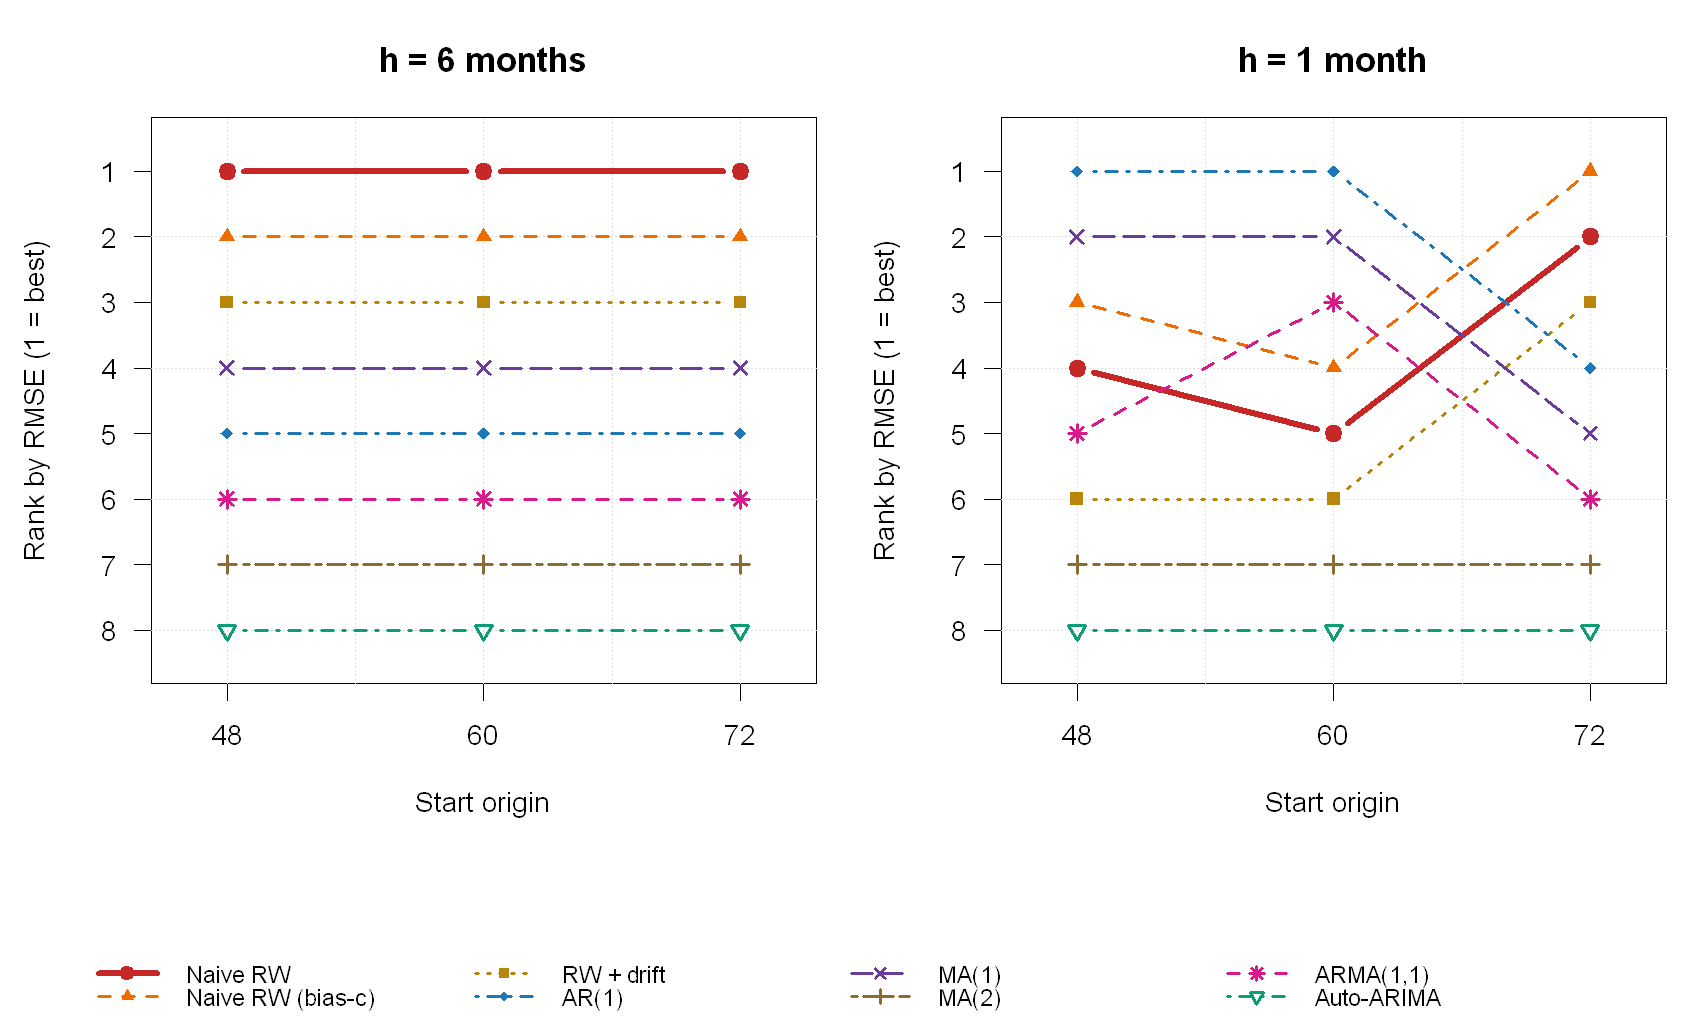

In [8]:
options(repr.plot.width = 10, repr.plot.height = 6)
par(mfrow = c(1, 2), mar = c(4.5, 4.5, 3.5, 1), oma = c(5.5, 0, 0, 0))
for (hh in c(6, 1)) {
  plot(NA, xlim = c(0.8, 3.2), ylim = c(8.5, 0.5), xaxt = "n", yaxt = "n",
       xlab = "Start origin", ylab = "Rank by RMSE (1 = best)",
       main = sprintf("h = %d month%s", hh, if (hh == 1) "" else "s"))
  axis(1, at = 1:3, labels = starts, lwd = 0, lwd.ticks = 1)
  axis(2, at = 1:8, las = 1, lwd = 0, lwd.ticks = 1)
  grid(col = "grey88")
  for (nm in model_order) {
    r <- sapply(starts, function(s) {
      sub <- all_m[all_m$start_origin == s & all_m$h == hh, ]
      rank(sub$RMSE, ties.method = "min")[which(sub$model == nm)]
    })
    lines(1:3, r, col = cols[nm], type = "b", pch = pchs[nm],
          lwd = lwds[nm], lty = ltys[nm])
  }
}
par(fig = c(0, 1, 0, 1), oma = c(0, 0, 0, 0), mar = c(0, 0, 0, 0), new = TRUE)
plot(0, 0, type = "n", bty = "n", xaxt = "n", yaxt = "n")
legend("bottom", ncol = 4, bty = "n", cex = 0.8,
       legend = model_order, col = cols[model_order],
       lwd = lwds[model_order], lty = ltys[model_order], pch = pchs[model_order])
par(mfrow = c(1, 1))

In [9]:
all_dm <- do.call(rbind, lapply(starts, function(s) {
  suffix <- if (s == 60) "" else paste0("_start", s)
  x <- read.csv(sprintf("results/dm_tests%s.csv", suffix), stringsAsFactors = FALSE)
  x$start_origin <- s
  x
}))
d1 <- all_dm[all_dm$h == 1, ]
mods <- setdiff(model_order, "Naive RW")
tab <- data.frame(model = mods, stringsAsFactors = FALSE)
for (s in starts) {
  tab[[paste0("CW_p_", s)]] <- sapply(mods, function(nm)
    round(d1$cw_p[d1$start_origin == s & d1$model == nm], 3))
}
tab$sig_at_all_starts <- apply(tab[, -1], 1, function(v) all(v < 0.05))
cat("Clark-West p-values at h = 1\n\n")
print(tab, row.names = FALSE)

Clark-West p-values at h = 1



             model CW_p_48 CW_p_60 CW_p_72 sig_at_all_starts
 Naive RW (bias-c)   0.349   0.357   0.341             FALSE
        RW + drift   0.680   0.671   0.578             FALSE
             AR(1)   0.072   0.071   0.187             FALSE
             MA(1)   0.036   0.034   0.133             FALSE
             MA(2)   0.056   0.056   0.198             FALSE
         ARMA(1,1)   0.043   0.041   0.152             FALSE
        Auto-ARIMA   0.116   0.120   0.449             FALSE


At six months all eight methods hold the **identical rank order in all three
backtests**, with the naive walk first every time.

At one month nothing holds still. The two significant Clark-West results rise to
0.133 and 0.152 when the backtest starts twelve months later. **No model is
significant at all three starts** — those p-values were an artefact of the start
origin, not evidence of skill.

## 6. Conclusion

**No ARIMA specification tested here forecasts monthly Brent better than assuming
next month's price equals this month's.**

- At 6 and 12 months the naive random walk is the most accurate method, in every
  backtest configuration, and the ranking of all eight methods is identical
  across three independent backtests.
- At 1 month the differences are within about 1%, the ordering is unstable, and
  no model is significantly better under either test.
- Auto-ARIMA, which won the single hold-out comparison in the coursework, ranks
  last at h=1 and h=6 across all three backtests. Its apparent advantage did not
  survive being tested more than once.

### What this does not show

The sample is 135 monthly observations of one commodity from one source, so it
bounds what any of this can settle. Only linear conditional-mean models are
fitted: the original analysis found clear volatility clustering and non-normal
residuals, and a GARCH-family model would address that directly, but nothing
here speaks to volatility forecasting. And a negative result is not proof of
absence — this shows these models on this series do not beat a random walk, not
that none could.

The honest summary is the one an efficient-markets argument would predict:
monthly oil prices are close to a random walk, and fitting ARIMA to their
returns does not change that.